In [102]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import norm

In [103]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVECSV = False

### Data Preparation and Preprocessing

In [104]:
# import dataframe with both real data and simulation data
with open("simu1_data/simu1_behav.pkl", "rb") as inp:
    df = pickle.load(inp)
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547


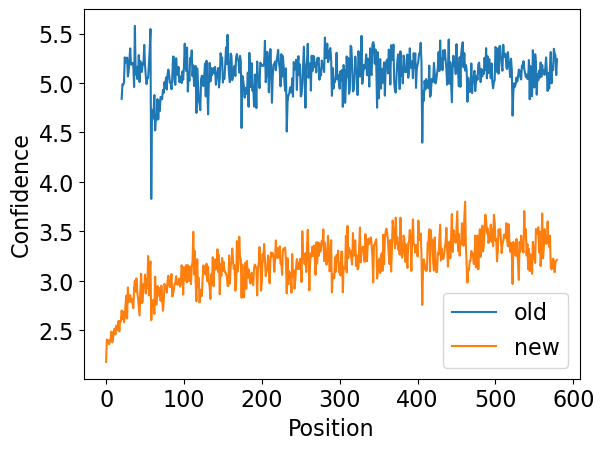

In [105]:
old_conf_pos = df.query("old == True").groupby("position").confidence.mean()
old_pos = np.unique(df.query("old == True").position.values)
new_conf_pos = df.query("old == False").groupby("position").confidence.mean()
new_pos = np.unique(df.query("old == False").position.values)

plt.plot(old_pos, old_conf_pos, label="old")
plt.plot(new_pos, new_conf_pos, label="new")
plt.xlabel("Position")
plt.ylabel("Confidence")
plt.legend()
plt.show()

In [106]:
# calculate the rolling category length
rolling_window = 9
category_label_dummies = df["category_label"].str.get_dummies()
category_label_dummies.columns = ["cl_" + col for col in category_label_dummies.columns]
category_label_dummies_events = pd.concat([df, category_label_dummies], axis=1)  # record the occurrence of every cat label
cl_rolling_sum = category_label_dummies_events.groupby("subject_ID").rolling(rolling_window, min_periods=1, on="position")[category_label_dummies.columns].sum().reset_index()
df_rollcat = df.merge(cl_rolling_sum, on=["subject_ID", "position"])
df["roll_cat_label_length"] = df_rollcat.apply(lambda x: x["cl_" + x["category_label"]], axis=1)  # how many cat within 9 window
df["roll_cat_label_length"] = df["roll_cat_label_length"] - 1  # how many cat in previous 8 window, not include self

# add rolling category length level
df["roll_cat_len_level"] = pd.cut(x=df.roll_cat_label_length, bins=[0, 2, np.inf], right=False, include_lowest=True, labels=["0-1", ">=2"]).astype("str")
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session,roll_cat_label_length,roll_cat_len_level
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0,0.0,0-1
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0,0.0,0-1
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0,0.0,0-1
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0,1.0,0-1
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0,0.0,0-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547,2.0,>=2
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547,0.0,0-1
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547,3.0,>=2
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547,0.0,0-1


In [107]:
df["category_label"].str.get_dummies()

,Appliances,Beverages,Birds,BodyParts,Building,Clothing,Desserts,Electronics,FarmAnimals,Flowers,...,Landscapes,OceanAnimals,OfficeSupplies,Tools,Toys,Trees,Vegetables,Vehicles,Weather,Zoo
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
317836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
317837,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
317838,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
category_label_dummies

,cl_Appliances,cl_Beverages,cl_Birds,cl_BodyParts,cl_Building,cl_Clothing,cl_Desserts,cl_Electronics,cl_FarmAnimals,cl_Flowers,...,cl_Landscapes,cl_OceanAnimals,cl_OfficeSupplies,cl_Tools,cl_Toys,cl_Trees,cl_Vegetables,cl_Vehicles,cl_Weather,cl_Zoo
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
317836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
317837,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
317838,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
# add log and log lag bin
df["log_lag"] = np.log(df["lag"])
df["log_lag_bin"] = pd.cut(df["log_lag"], np.arange(df["log_lag"].max() + 1), labels=False, right=False)
df["log_lag_bin"] = df.apply(lambda x: 0 if x["log_lag_bin"] == 1 else x["log_lag_bin"], axis=1)
df["log_lag_bin"] = df.apply(lambda x: 5 if x["log_lag_bin"] > 5 else x["log_lag_bin"], axis=1)
df

/home1/beigejin/.conda/envs/CMR_IA/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session,roll_cat_label_length,roll_cat_len_level,log_lag,log_lag_bin
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0,0.0,0-1,-inf,NaN
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0,0.0,0-1,-inf,NaN
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0,0.0,0-1,-inf,NaN
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0,1.0,0-1,-inf,NaN
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0,0.0,0-1,-inf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547,2.0,>=2,3.610918,3.0
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547,0.0,0-1,4.744932,4.0
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547,3.0,>=2,3.178054,3.0
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547,0.0,0-1,3.713572,3.0


In [111]:
# construct local FAR
old_vec = df.old.to_numpy()
conf_vec = df.confidence.to_numpy()
log_lag_bin_vec = df.log_lag_bin.to_numpy()
position_vec = df.position.to_numpy()
log_lag_bin_newpre_lst = []
conf_newpre_lst = []
log_lag_bin_newpost_lst = []
conf_newpost_lst = []
for i in range(len(df)):
    if position_vec[i] > 0:
        if old_vec[i] == False and old_vec[i - 1] == True:
            log_lag_bin_newpre_lst.append(log_lag_bin_vec[i - 1])
            conf_newpre_lst.append(conf_vec[i - 1])
        else:
            log_lag_bin_newpre_lst.append("N")
            conf_newpre_lst.append("N")
    else:
        log_lag_bin_newpre_lst.append("N")
        conf_newpre_lst.append("N")

    if position_vec[i] < np.max(position_vec):
        if old_vec[i] == False and old_vec[i + 1] == True:
            log_lag_bin_newpost_lst.append(log_lag_bin_vec[i + 1])
            conf_newpost_lst.append(conf_vec[i + 1])
        else:
            log_lag_bin_newpost_lst.append("N")
            conf_newpost_lst.append("N")
    else:
        log_lag_bin_newpost_lst.append("N")
        conf_newpost_lst.append("N")

df["log_lag_bin_newpre"] = log_lag_bin_newpre_lst
df["conf_newpre"] = conf_newpre_lst
df["log_lag_bin_newpost"] = log_lag_bin_newpost_lst
df["conf_newpost"] = conf_newpost_lst
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,session,roll_cat_label_length,roll_cat_len_level,log_lag,log_lag_bin,is_prev_same_cat,log_lag_bin_newpre,conf_newpre,log_lag_bin_newpost,conf_newpost
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,...,0,0.0,0-1,-inf,NaN,False,N,N,N,N
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,...,0,0.0,0-1,-inf,NaN,False,N,N,N,N
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,...,0,0.0,0-1,-inf,NaN,False,N,N,N,N
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,...,0,1.0,0-1,-inf,NaN,False,N,N,N,N
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,...,0,0.0,0-1,-inf,NaN,False,N,N,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,547,2.0,>=2,3.610918,3.0,False,N,N,N,N
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,547,0.0,0-1,4.744932,4.0,False,N,N,N,N
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,547,3.0,>=2,3.178054,3.0,False,N,N,N,N
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,547,0.0,0-1,3.713572,3.0,False,N,N,N,N


1~7 -> 1(0,1), 8~20 -> 8(2), 21~54 -> 21(3), 55~148 -> 55(4), >=149 -> 149(5)

In [112]:
# distribute items into bins
log_lag_bins = [0, 2, 3, 4, 5]
for bin in log_lag_bins:
    col_name = "log_lag_bin_" + str(bin)
    # df[col_name] = (df.log_lag_bin == bin) | (df.log_lag_bin_newpre == bin) | (df.log_lag_bin_newpost == bin)
    df[col_name] = (df.log_lag_bin == bin) | (df.log_lag_bin_newpre == bin)
    # df[col_name] = (df.log_lag_bin == bin) | (df.log_lag_bin_newpost == bin)  # alleviate the initial dip for high sim in simulation
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,is_prev_same_cat,log_lag_bin_newpre,conf_newpre,log_lag_bin_newpost,conf_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,...,False,N,N,N,N,False,False,False,False,False
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,...,False,N,N,N,N,False,False,False,False,False
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,...,False,N,N,N,N,False,False,False,False,False
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,...,False,N,N,N,N,False,False,False,False,False
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,...,False,N,N,N,N,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,False,N,N,N,N,False,False,True,False,False
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,False,N,N,N,N,False,False,False,True,False
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,False,N,N,N,N,False,False,True,False,False
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,False,N,N,N,N,False,False,True,False,False


In [113]:
df.groupby(["old", "log_lag_bin", "roll_cat_len_level"]).yes.count()

old   log_lag_bin  roll_cat_len_level
True  0.0          0-1                    9479
                   >=2                   18654
      2.0          0-1                   23905
                   >=2                    9054
      3.0          0-1                   39599
                   >=2                    4337
      4.0          0-1                   29760
                   >=2                    1867
      5.0          0-1                    6719
                   >=2                     291
Name: yes, dtype: int64

<Axes: xlabel='lag', ylabel='Count'>

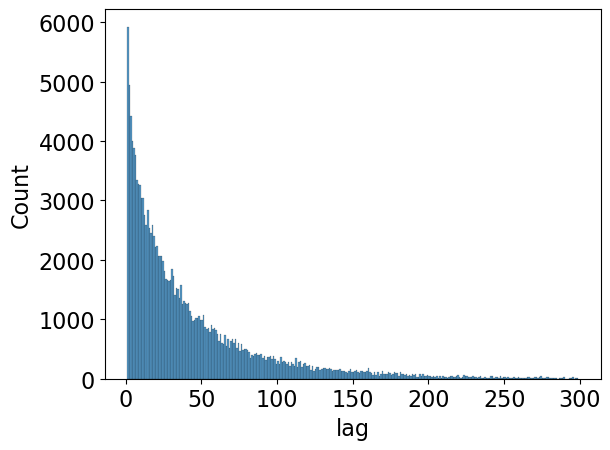

In [114]:
# plot the distribution of lags in df
fig, ax = plt.subplots()
sns.histplot(df.query("lag > 0"), x="lag", ax=ax, bins=np.arange(1, 300))

### Lag Group and Roll Cat

In [115]:
def get_roll_cat_distance(df_tmp):
    cat_labels = df_tmp.category_label.to_numpy()
    roll_cat_lens = df_tmp.roll_cat_label_length.to_numpy()
    res = []
    for i in range(len(cat_labels)):
        now_cat = cat_labels[i]
        now_roll_cat_len = roll_cat_lens[i]
        if now_roll_cat_len == 0:
            res.append(np.array([]))
        else:
            all_cat = np.where(cat_labels == now_cat)[0]
            all_cat_idx = np.where(all_cat == i)[0].item()
            relevant_cat_pos = all_cat[int((all_cat_idx - now_roll_cat_len)) : all_cat_idx]
            res.append(relevant_cat_pos - i)
    return res


df["roll_cat_distance"] = df.groupby("session").apply(get_roll_cat_distance).explode().to_numpy()
df["max_roll_cat_distance"] = df["roll_cat_distance"].apply(lambda x: np.max(x) if len(x) > 0 else 0)
df["mean_roll_cat_distance"] = df["roll_cat_distance"].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
df["effect_roll_cat_distance"] = df["roll_cat_distance"].apply(lambda x: np.sum(9 + x) if len(x) > 0 else 0)
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,conf_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5,roll_cat_distance,max_roll_cat_distance,mean_roll_cat_distance,effect_roll_cat_distance
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,...,N,False,False,False,False,False,[],0,0.000000,0
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,...,N,False,False,False,False,False,[],0,0.000000,0
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,...,N,False,False,False,False,False,[],0,0.000000,0
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,...,N,False,False,False,False,False,[-2],-2,-2.000000,7
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,...,N,False,False,False,False,False,[],0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,N,False,False,True,False,False,"[-4, -3]",-3,-3.500000,11
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,N,False,False,False,True,False,[],0,0.000000,0
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,N,False,False,True,False,False,"[-6, -5, -2]",-2,-4.333333,14
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,N,False,False,True,False,False,[],0,0.000000,0


In [116]:
df_copy = df.copy()

In [117]:
df = df_copy.copy()
df = df.query("position >= 20")
df = df.query("roll_cat_label_length <= 2")
df = df.query("old == True or max_roll_cat_distance == -1")
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,conf_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5,roll_cat_distance,max_roll_cat_distance,mean_roll_cat_distance,effect_roll_cat_distance
21,829.330,0,LEMON,18,Uncategorized,1.0,Fruit,21,True,0.0,...,N,False,True,False,False,False,[],0,0.0,0
23,1116.505,0,CROW,15,Birds,8.0,Birds,23,True,1.0,...,N,False,True,False,False,False,[],0,0.0,0
25,827.260,0,CALCULATOR,1,Uncategorized-Singleton,8.0,Electronics,25,True,1.0,...,N,True,False,False,False,False,[-1],-1,-1.0,8
26,1204.710,0,BUS,24,Uncategorized,8.0,Vehicles,26,True,1.0,...,N,False,False,True,False,False,[],0,0.0,0
33,699.330,0,EYE,0,BodyParts,1.0,BodyParts,33,False,0.0,...,8.0,False,False,False,False,False,[-1],-1,-1.0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317834,1450.000,656,PEELER,57,Uncategorized-Singleton,1.0,KitchenTools,574,True,0.0,...,N,False,False,False,True,False,[],0,0.0,0
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,N,False,False,True,False,False,"[-4, -3]",-3,-3.5,11
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,N,False,False,False,True,False,[],0,0.0,0
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,N,False,False,True,False,False,[],0,0.0,0


In [118]:
# calculate overall HR and FAR
df_overall = df.groupby(["session", "roll_cat_len_level", "old"])["yes"].mean().reset_index()
df_overall.groupby(["roll_cat_len_level", "old"])["yes"].mean()

roll_cat_len_level  old  
0-1                 False    0.279449
                    True     0.661930
>=2                 False    0.276530
                    True     0.706959
Name: yes, dtype: float64

In [119]:
df_lst = []
for bin in log_lag_bins:
    col_name = "log_lag_bin_" + str(bin)
    df_tmp = df.query(col_name + " == True").groupby(["subject_ID", "old", "roll_cat_len_level"])["yes"].agg(["mean", "sum", "count"]).reset_index()
    # df_tmp = df.query(col_name + " == True").groupby(["subject_ID", "old", "roll_cat_len_level"])["confidence"].agg(["mean", "sum", "count"]).reset_index()
    df_tmp["log_lag_bin"] = bin
    df_lst.append(df_tmp)
df_rollcat_laggp = pd.concat(df_lst)
df_rollcat_laggp.rename(columns={"mean": "yes_rate"}, inplace=True)
df_rollcat_laggp["yes_rate_adj"] = (df_rollcat_laggp["sum"] + 0.5) / (df_rollcat_laggp["count"] + 1)
df_rollcat_laggp

,subject_ID,old,roll_cat_len_level,yes_rate,sum,count,log_lag_bin,yes_rate_adj
0,0,False,>=2,0.222222,2.0,9,0,0.250000
1,0,True,0-1,0.971429,34.0,35,0,0.958333
2,0,True,>=2,1.000000,21.0,21,0,0.977273
3,1,False,>=2,0.500000,1.0,2,0,0.500000
4,1,True,0-1,0.916667,11.0,12,0,0.884615
...,...,...,...,...,...,...,...,...
660,654,True,0-1,0.666667,8.0,12,5,0.653846
661,655,True,0-1,0.291667,7.0,24,5,0.300000
662,655,True,>=2,0.000000,0.0,1,5,0.250000
663,656,True,0-1,0.727273,8.0,11,5,0.708333


In [120]:
# log lag for display
df_rollcat_laggp["log_lag_disp"] = np.ceil(np.e**df_rollcat_laggp.log_lag_bin)
df_rollcat_laggp

,subject_ID,old,roll_cat_len_level,yes_rate,sum,count,log_lag_bin,yes_rate_adj,log_lag_disp
0,0,False,>=2,0.222222,2.0,9,0,0.250000,1.0
1,0,True,0-1,0.971429,34.0,35,0,0.958333,1.0
2,0,True,>=2,1.000000,21.0,21,0,0.977273,1.0
3,1,False,>=2,0.500000,1.0,2,0,0.500000,1.0
4,1,True,0-1,0.916667,11.0,12,0,0.884615,1.0
...,...,...,...,...,...,...,...,...,...
660,654,True,0-1,0.666667,8.0,12,5,0.653846,149.0
661,655,True,0-1,0.291667,7.0,24,5,0.300000,149.0
662,655,True,>=2,0.000000,0.0,1,5,0.250000,149.0
663,656,True,0-1,0.727273,8.0,11,5,0.708333,149.0


In [121]:
df_rollcat_laggp.groupby(["old", "log_lag_bin", "roll_cat_len_level"])["count"].sum()

old    log_lag_bin  roll_cat_len_level
False  0            >=2                    1261
       2            0-1                     286
                    >=2                     193
       3            0-1                     377
                    >=2                     190
       4            0-1                     181
                    >=2                     108
       5            0-1                      48
                    >=2                      15
True   0            0-1                    9479
                    >=2                    6196
       2            0-1                   23905
                    >=2                    4370
       3            0-1                   39599
                    >=2                    2778
       4            0-1                   29760
                    >=2                    1263
       5            0-1                    6719
                    >=2                     207
Name: count, dtype: int64

In [122]:
df_rollcat_laggp.query("old == False and log_lag_disp == 149")

,subject_ID,old,roll_cat_len_level,yes_rate,sum,count,log_lag_bin,yes_rate_adj,log_lag_disp
17,21,False,0-1,1.0,1.0,1,5,0.750000,149.0
21,23,False,>=2,NaN,0.0,0,5,0.500000,149.0
34,41,False,>=2,0.0,0.0,1,5,0.250000,149.0
36,42,False,0-1,0.0,0.0,1,5,0.250000,149.0
41,48,False,0-1,0.0,0.0,1,5,0.250000,149.0
54,63,False,>=2,1.0,1.0,1,5,0.750000,149.0
57,65,False,0-1,1.0,1.0,1,5,0.750000,149.0
69,77,False,0-1,1.0,1.0,1,5,0.750000,149.0
70,77,False,>=2,1.0,1.0,1,5,0.750000,149.0
88,93,False,0-1,1.0,1.0,1,5,0.750000,149.0


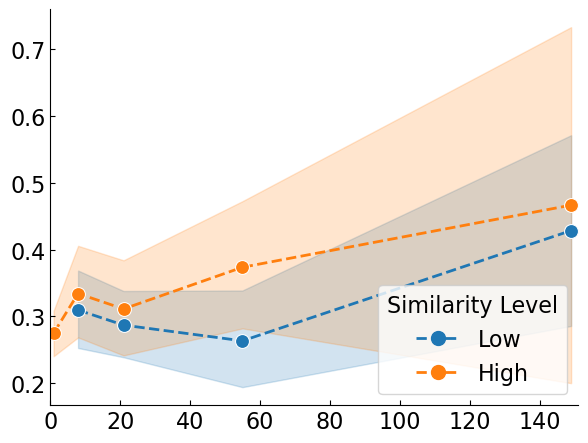

In [123]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_rollcat_laggp.query("old == False").reset_index(), y="yes_rate", x="log_lag_disp", hue="roll_cat_len_level", hue_order=["0-1", ">=2"], marker="o", markersize=10, linestyle="--", lw=2, ax=ax)
plt.ylabel('P("Yes" | New)')
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.xticks(ticks=np.arange(0, 160, 20))
# plt.yticks(ticks=np.arange(0.14, 0.40, 0.02))
# plt.ylim([0.25, 0.35])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level", loc="lower right")

if SAVEFIG:
    plt.savefig(f"simu1_fig/simu1_David_far.pdf")

### NEW

In [227]:
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,is_prev_same_cat,log_lag_bin_newpre,conf_newpre,log_lag_bin_newpost,conf_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
20,812.780,0,FUDGE,0,Uncategorized,1.0,Desserts,20,False,0.0,...,False,N,N,2.0,1.0,False,False,False,False,False
21,829.330,0,LEMON,18,Uncategorized,1.0,Fruit,21,True,0.0,...,False,N,N,N,N,False,True,False,False,False
22,911.690,0,GORILLA,0,Uncategorized,1.0,Zoo,22,False,0.0,...,False,2.0,1.0,2.0,8.0,False,True,False,False,False
23,1116.505,0,CROW,15,Birds,8.0,Birds,23,True,1.0,...,False,N,N,N,N,False,True,False,False,False
24,1588.425,0,CALCULATOR,0,Uncategorized-Singleton,1.0,Electronics,24,False,0.0,...,False,2.0,8.0,0.0,8.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,False,N,N,N,N,False,False,True,False,False
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,False,N,N,N,N,False,False,False,True,False
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,False,N,N,N,N,False,False,True,False,False
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,False,N,N,N,N,False,False,True,False,False


In [171]:
df.query("log_lag_bin_newpre == 0 and roll_cat_len_level == '>=2'").groupby("subject_ID").confidence.mean().mean()

3.289475197263698

In [167]:
df.query("log_lag_bin_newpre == 2 and roll_cat_len_level == '>=2'").groupby("subject_ID").confidence.mean().mean()

3.392925348289281

In [168]:
df.query("log_lag_bin_newpre == 3 and roll_cat_len_level == '>=2'").groupby("subject_ID").confidence.mean().mean()

3.29488507020858

In [172]:
df.query("log_lag_bin_newpre == 4 and roll_cat_len_level == '>=2'").groupby("subject_ID").confidence.mean().mean()

3.36196586256278

In [173]:
df.query("log_lag_bin_newpre == 5 and roll_cat_len_level == '>=2'").groupby("subject_ID").confidence.mean().mean()

3.583386243386243

In [174]:
df.query("log_lag_bin_newpre == 0 and roll_cat_len_level == '>=2'").groupby("subject_ID").roll_cat_label_length.mean().mean()

2.823291939267116

In [175]:
df.query("log_lag_bin_newpre == 2 and roll_cat_len_level == '>=2'").groupby("subject_ID").roll_cat_label_length.mean().mean()

2.6557604851458376

In [176]:
df.query("log_lag_bin_newpre == 3 and roll_cat_len_level == '>=2'").groupby("subject_ID").roll_cat_label_length.mean().mean()

2.6124547289693276

In [177]:
df.query("log_lag_bin_newpre == 4 and roll_cat_len_level == '>=2'").groupby("subject_ID").roll_cat_label_length.mean().mean()

2.691319432488691

In [178]:
df.query("log_lag_bin_newpre == 5 and roll_cat_len_level == '>=2'").groupby("subject_ID").roll_cat_label_length.mean().mean()

2.649890782000874

In [259]:
df.query("log_lag_bin_newpre == 0 and roll_cat_label_length == 2 and is_prev_same_cat == False").groupby("subject_ID").confidence.mean().mean()

3.302538902538902

In [260]:
df.query("log_lag_bin_newpre == 2 and roll_cat_label_length == 2 and is_prev_same_cat == False").groupby("subject_ID").confidence.mean().mean()

3.3752269037780405

In [244]:
df.query("log_lag_bin_newpre == 2 and roll_cat_label_length == 2 and is_prev_same_cat == True").confidence.count()

193

In [228]:
df.query("log_lag_bin_newpost == 0 and roll_cat_len_level == '>=2'").yes.mean()

0.27307383627608345

In [229]:
df.query("log_lag_bin_newpost == 2 and roll_cat_len_level == '>=2'").yes.mean()

0.28826213189547906

In [74]:
df.query("log_lag_bin_newpost == 0 and roll_cat_len_level == '>=2'").roll_cat_label_length.mean()

3.167146053052093

In [75]:
df.query("log_lag_bin_newpost == 2 and roll_cat_len_level == '>=2'").roll_cat_label_length.mean()

2.977329082536309

In [94]:
df2 = df.query("log_lag_bin_newpre != 'N' and roll_cat_label_length <=4").copy()
df2

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,log_lag_bin,log_lag_bin_newpre,conf_newpre,log_lag_bin_newpost,conf_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
22,911.690,0,GORILLA,0,Uncategorized,1.0,Zoo,22,False,0.0,...,NaN,2.0,1.0,2.0,8.0,False,True,False,False,False
24,1588.425,0,CALCULATOR,0,Uncategorized-Singleton,1.0,Electronics,24,False,0.0,...,NaN,2.0,8.0,0.0,8.0,True,False,False,False,False
27,1792.695,0,ORANGE,0,Uncategorized,3.0,Fruit,27,False,0.0,...,NaN,3.0,8.0,N,N,False,False,False,False,False
37,1981.375,0,FINGERS,0,BodyParts,3.0,BodyParts,37,False,0.0,...,NaN,3.0,8.0,3.0,8.0,False,False,True,False,False
39,1344.225,0,ROOF,0,Building,1.0,Building,39,False,0.0,...,NaN,3.0,8.0,3.0,8.0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317786,1515.000,656,WOODS,0,Landscapes,1.0,Landscapes,526,False,0.0,...,NaN,3.0,8.0,N,N,False,False,False,False,False
317790,1822.000,656,SNOW,0,Weather,2.0,Weather,530,False,0.0,...,NaN,4.0,8.0,N,N,False,False,False,False,False
317793,2603.000,656,TORNADO,0,Weather,7.0,Weather,533,False,1.0,...,NaN,2.0,8.0,N,N,False,False,False,False,False
317802,2009.000,656,LEMONADE,0,Beverages,1.0,Beverages,542,False,0.0,...,NaN,0.0,4.0,N,N,False,False,False,False,False


In [80]:
# linear regression on the effect of log lag bin on yes rate using smf
import statsmodels.formula.api as smf

In [95]:
model = smf.ols("confidence ~ roll_cat_label_length + position", data=df2)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             confidence   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     264.8
Date:                Thu, 27 Mar 2025   Prob (F-statistic):          2.66e-115
Time:                        18:51:00   Log-Likelihood:            -1.4794e+05
No. Observations:               68254   AIC:                         2.959e+05
Df Residuals:                   68251   BIC:                         2.959e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.8582      0.018    157.893      0.000       2.823       2.894
roll_cat_label_length     0.0449      0.007      6.856      0.000       0.032       0.058
position                  0.0011   5.17e-05     21.405      0.000       0.001       0.001
==============================================================================
Omnibus:                     7410.360   Durbin-Watson:                   1.371
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5349.109
Skew:                           0.582   Prob(JB):                         0.00
Kurtosis:                       2.274   Cond. No.                         744.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='position', ylabel='confidence'>

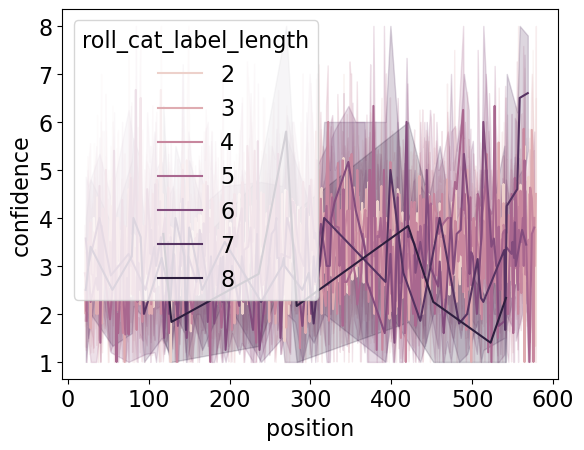

In [82]:
sns.lineplot(data=df2.query("roll_cat_label_length < 5"), x="position", y="confidence", hue="roll_cat_label_length")

<Axes: xlabel='roll_cat_label_length', ylabel='confidence'>

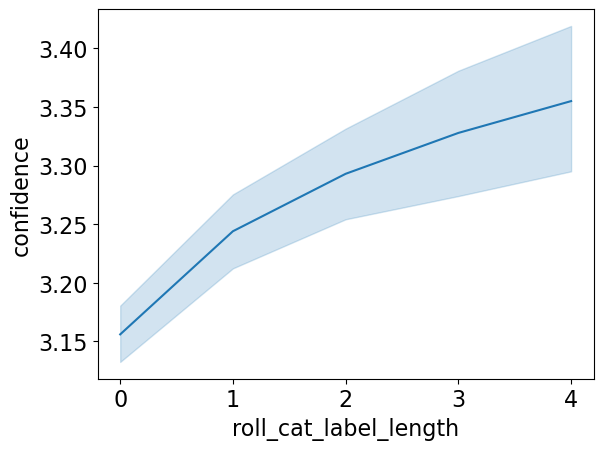

In [96]:
sns.lineplot(data=df2.query("roll_cat_label_length <= 6"), x="roll_cat_label_length", y="confidence")

#### FAR

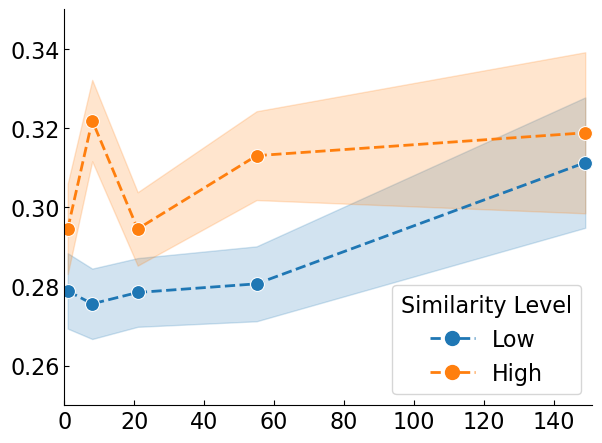

In [139]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_dprime, y="far", x="log_lag_disp", hue="roll_cat_len_level", marker="o", markersize=10, linestyle="--", lw=2, ax=ax, errorbar="se")
plt.ylabel('P("Yes" | New)')
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.xticks(ticks=np.arange(0, 160, 20))
plt.yticks(ticks=np.arange(0.14, 0.40, 0.02))
plt.ylim([0.25, 0.35])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level", loc="lower right")

if SAVEFIG:
    plt.savefig(f"simu1_fig/simu1_David_far.pdf")